In [1]:
# %% [markdown]
# Case 01 – Initial exploration

# %%
import pandas as pd
import numpy as np

df = pd.read_csv("../data/billing.csv")
df.head()

,usage_date,billing_period,account_id,account_name,business_unit,environment,region,service_name,product_name,team,...,sla_tier,budget_amount,forecast_baseline_cost,acquisition_phase,tag_owner,tag_environment,tag_product,tag_cost_center,allocation_status,anomaly_flag
0,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,AWS Fargate,ai-assistant,ml-engineering,...,premium,98400.73,97716.41,pre-integration,ml-engineering,staging,ai-assistant,core-platform,allocated,0
1,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Fargate,workflow-intelligence,product-analytics,...,standard,271679.01,258624.24,pre-integration,product-analytics,dev,NaN,core-platform,allocated,0
2,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,prod,us-east-1,AWS Lambda,ai-assistant,data,...,enterprise,216109.16,199963.24,pre-integration,data,prod,ai-assistant,core-platform,allocated,0
3,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Lambda,workflow-intelligence,product-analytics,...,standard,194208.81,191883.15,pre-integration,product-analytics,dev,NaN,core-platform,partially-allocated,0
4,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,Amazon CloudWatch,reporting-api,ml-engineering,...,premium,101965.35,102659.37,pre-integration,ml-engineering,staging,reporting-api,core-platform,allocated,0


In [2]:
import plotly
print(plotly.__version__)

6.7.0


In [3]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots

In [4]:
df

,usage_date,billing_period,account_id,account_name,business_unit,environment,region,service_name,product_name,team,...,sla_tier,budget_amount,forecast_baseline_cost,acquisition_phase,tag_owner,tag_environment,tag_product,tag_cost_center,allocation_status,anomaly_flag
0,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,AWS Fargate,ai-assistant,ml-engineering,...,premium,98400.73,97716.41,pre-integration,ml-engineering,staging,ai-assistant,core-platform,allocated,0
1,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Fargate,workflow-intelligence,product-analytics,...,standard,271679.01,258624.24,pre-integration,product-analytics,dev,NaN,core-platform,allocated,0
2,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,prod,us-east-1,AWS Lambda,ai-assistant,data,...,enterprise,216109.16,199963.24,pre-integration,data,prod,ai-assistant,core-platform,allocated,0
3,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,dev,us-east-1,AWS Lambda,workflow-intelligence,product-analytics,...,standard,194208.81,191883.15,pre-integration,product-analytics,dev,NaN,core-platform,partially-allocated,0
4,2025-10-01,2025-10,1001,legacy-core-prod,core-platform,staging,us-east-1,Amazon CloudWatch,reporting-api,ml-engineering,...,premium,101965.35,102659.37,pre-integration,ml-engineering,staging,reporting-api,core-platform,allocated,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2026-01-28,2026-01,1003,shared-services,shared-ops,prod,us-east-1,Amazon RDS,reporting-api,product-analytics,...,standard,136186.09,142806.35,post-integration,product-analytics,prod,reporting-api,shared-ops,partially-allocated,0
4996,2026-01-28,2026-01,1003,shared-services,shared-ops,dev,us-east-1,Amazon RDS,workflow-intelligence,data,...,enterprise,205486.34,210626.57,post-integration,data,dev,workflow-intelligence,shared-ops,allocated,0
4997,2026-01-28,2026-01,1003,shared-services,shared-ops,prod,us-east-1,Amazon RDS,ai-assistant,product-analytics,...,standard,129461.87,135340.90,post-integration,product-analytics,prod,ai-assistant,shared-ops,partially-allocated,0
4998,2026-01-28,2026-01,1003,shared-services,shared-ops,prod,us-east-1,NAT Gateway,ai-assistant,platform,...,standard,115124.18,123360.32,post-integration,NaN,prod,ai-assistant,shared-ops,allocated,0


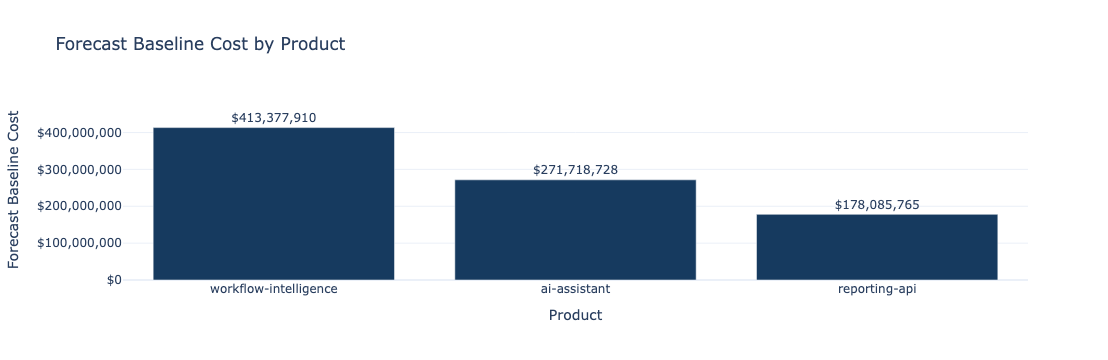

In [7]:
#plotly view of forecasted baseline cost, per product

forecast_by_product = (
    df.groupby("product_name", dropna=False)["forecast_baseline_cost"]
      .sum()
      .reset_index()
      .sort_values("forecast_baseline_cost", ascending=False)
)

fig = px.bar(
    forecast_by_product,
    x="product_name",
    y="forecast_baseline_cost",
    text="forecast_baseline_cost",
    title="Forecast Baseline Cost by Product"
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside",
    marker_color="#163A5F"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Product",
    yaxis_title="Forecast Baseline Cost",
    yaxis_tickprefix="$",
    yaxis_tickformat=",.0f",
    showlegend=False
)

fig.show()

In [8]:
forecast_by_sla = (
    df.groupby("sla_tier")["forecast_baseline_cost"]
      .sum()
      .reset_index()
      .sort_values("forecast_baseline_cost", ascending=False)
)

forecast_by_sla


,sla_tier,forecast_baseline_cost
2,standard,3.756080e+08
1,premium,3.140796e+08
0,enterprise,1.734948e+08


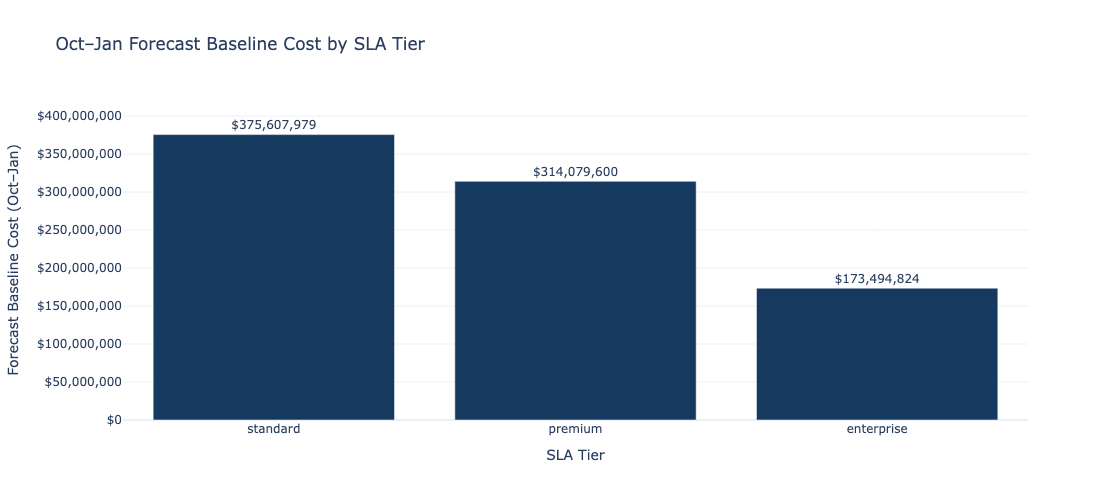

In [9]:
# view in dollars

fig = px.bar(
    forecast_by_sla,
    x="sla_tier",
    y="forecast_baseline_cost",
    text="forecast_baseline_cost",
    title="Oct–Jan Forecast Baseline Cost by SLA Tier",
)

fig.update_traces(
    texttemplate="$%{text:,.0f}",
    textposition="outside",
    marker_color="#163A5F",
    hovertemplate="<b>%{x}</b><br>Forecast Baseline Cost: $%{y:,.0f}<extra></extra>"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="SLA Tier",
    yaxis_title="Forecast Baseline Cost (Oct–Jan)",
    yaxis_tickformat="$,.0f",
    showlegend=False,
    height=500,
)

fig.show()

In [10]:
# check for what all columns are

df.columns.tolist()

['usage_date',
 'billing_period',
 'account_id',
 'account_name',
 'business_unit',
 'environment',
 'region',
 'service_name',
 'product_name',
 'team',
 'cost_usd',
 'usage_quantity',
 'usage_unit',
 'monthly_revenue_proxy',
 'active_customers',
 'workflows_processed',
 'enterprise_customer_flag',
 'sla_tier',
 'budget_amount',
 'forecast_baseline_cost',
 'acquisition_phase',
 'tag_owner',
 'tag_environment',
 'tag_product',
 'tag_cost_center',
 'allocation_status',
 'anomaly_flag']

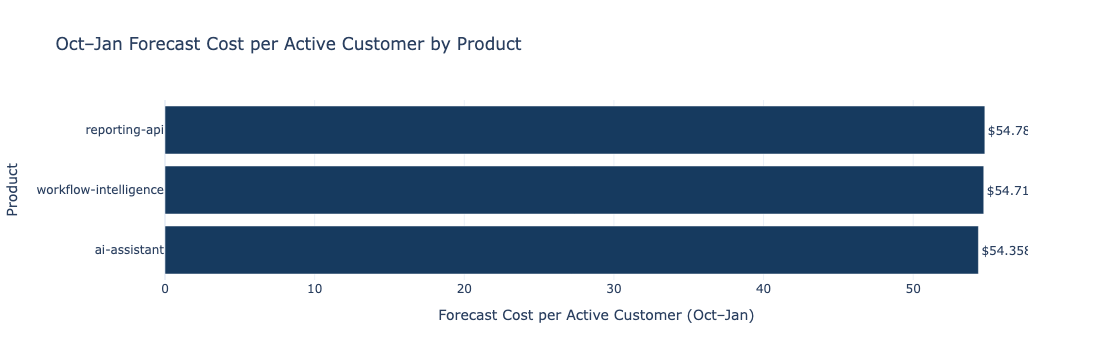

In [11]:
# checking cloud efficiency per customer

unit_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "active_customers": "sum",
      })
      .reset_index()
)

unit_df["cost_per_customer"] = (
    unit_df["forecast_baseline_cost"] / unit_df["active_customers"]
)

unit_df = unit_df.sort_values("cost_per_customer", ascending=True)

fig = px.bar(
    unit_df,
    x="cost_per_customer",
    y="product_name",
    orientation="h",
    text="cost_per_customer",
    title="Oct–Jan Forecast Cost per Active Customer by Product",
)

fig.update_traces(
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    marker_color="#163A5F",
    hovertemplate="<b>%{y}</b><br>Cost per customer: $%{x:,.4f}<extra></extra>",
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Forecast Cost per Active Customer (Oct–Jan)",
    yaxis_title="Product",
    showlegend=False,
)

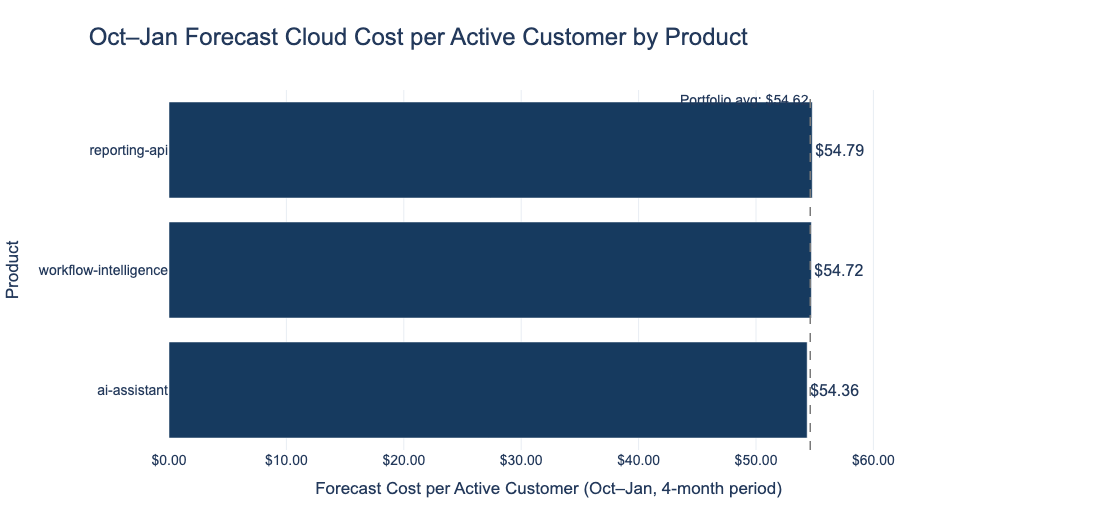

In [12]:
# better version

import numpy as np
import pandas as pd
import plotly.express as px

# Aggregate to product level
unit_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "active_customers": "sum",
      })
      .reset_index()
)

# Guard against divide-by-zero
unit_df = unit_df[unit_df["active_customers"] > 0].copy()

# Unit metric
unit_df["cost_per_customer"] = (
    unit_df["forecast_baseline_cost"] / unit_df["active_customers"]
)

# Sort for cleaner reading
unit_df = unit_df.sort_values("cost_per_customer", ascending=True)

# Portfolio average
portfolio_avg = unit_df["cost_per_customer"].mean()

fig = px.bar(
    unit_df,
    x="cost_per_customer",
    y="product_name",
    orientation="h",
    text="cost_per_customer",
    title="Oct–Jan Forecast Cloud Cost per Active Customer by Product",
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.2f}",
    textposition="outside",
    cliponaxis=False,
    outsidetextfont=dict(size=16, color="#23395B"),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Forecast cost per active customer: $%{x:,.2f}"
        "<extra></extra>"
    ),
)

fig.add_vline(
    x=portfolio_avg,
    line_dash="dash",
    line_color="#7A7A7A",
    line_width=1.5,
    annotation_text=f"Portfolio avg: ${portfolio_avg:,.2f}",
    annotation_position="top left"
)

max_x = unit_df["cost_per_customer"].max()

fig.update_layout(
    template="plotly_white",
    height=520,
    showlegend=False,
    title=dict(
        x=0.08,
        xanchor="left",
        font=dict(size=24, color="#23395B")
    ),
    margin=dict(l=150, r=180, t=90, b=70),
    xaxis=dict(
        title="Forecast Cost per Active Customer (Oct–Jan, 4-month period)",
        tickprefix="$",
        tickformat=",.2f",
        showgrid=True,
        gridcolor="#E8EDF3",
        zeroline=False,
        range=[0, max_x * 1.18]
    ),
    yaxis=dict(
        title="Product",
        showgrid=False
    ),
    uniformtext_minsize=14,
    uniformtext_mode="show",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(
        family="Arial",
        size=14,
        color="#23395B"
    )
)

fig.show()

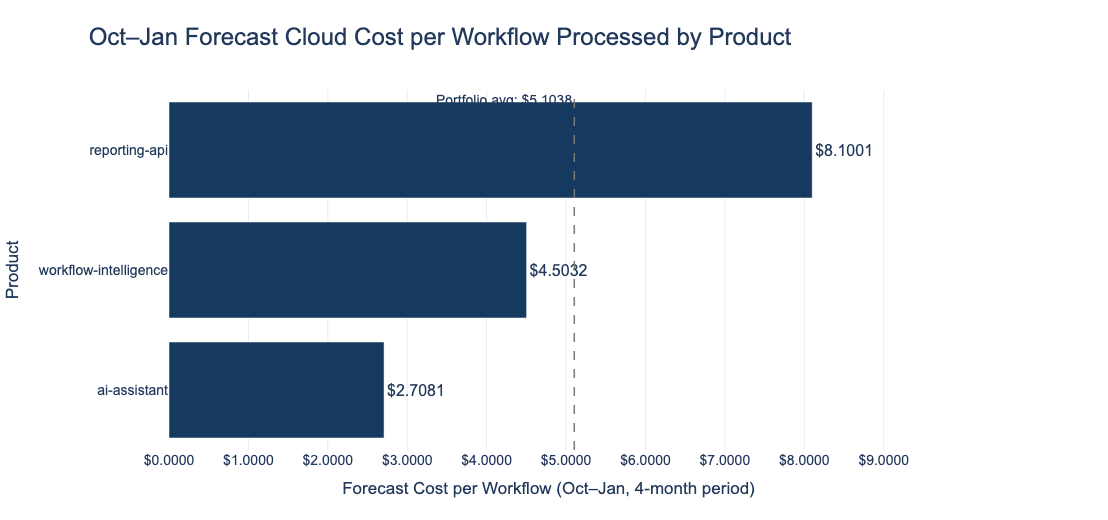

In [13]:
# checking cost per workflow processed

workflow_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

workflow_df = workflow_df[workflow_df["workflows_processed"] > 0].copy()

workflow_df["cost_per_workflow"] = (
    workflow_df["forecast_baseline_cost"] / workflow_df["workflows_processed"]
)

workflow_df = workflow_df.sort_values("cost_per_workflow", ascending=True)

workflow_avg = workflow_df["cost_per_workflow"].mean()

fig = px.bar(
    workflow_df,
    x="cost_per_workflow",
    y="product_name",
    orientation="h",
    text="cost_per_workflow",
    title="Oct–Jan Forecast Cloud Cost per Workflow Processed by Product",
)

fig.update_traces(
    marker_color="#163A5F",
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    outsidetextfont=dict(size=16, color="#23395B"),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Forecast cost per workflow: $%{x:,.4f}"
        "<extra></extra>"
    ),
)

max_x = workflow_df["cost_per_workflow"].max()

fig.add_vline(
    x=workflow_avg,
    line_dash="dash",
    line_color="#7A7A7A",
    line_width=1.5,
    annotation_text=f"Portfolio avg: ${workflow_avg:,.4f}",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    height=520,
    showlegend=False,
    title=dict(x=0.08, xanchor="left", font=dict(size=24, color="#23395B")),
    margin=dict(l=150, r=180, t=90, b=70),
    xaxis=dict(
        title="Forecast Cost per Workflow (Oct–Jan, 4-month period)",
        tickprefix="$",
        tickformat=",.4f",
        showgrid=True,
        gridcolor="#E8EDF3",
        zeroline=False,
        range=[0, max_x * 1.18]
    ),
    yaxis=dict(title="Product", showgrid=False),
    uniformtext_minsize=14,
    uniformtext_mode="show",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Arial", size=14, color="#23395B")
)

fig.show()

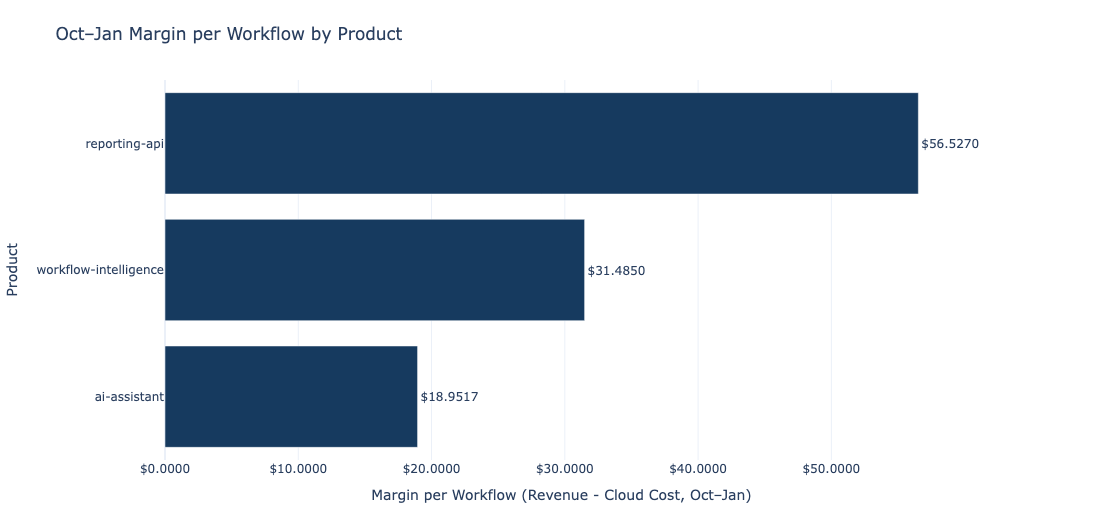

In [16]:
margin_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
          "workflows_processed": "sum"
      })
      .reset_index()
)

margin_df = margin_df[margin_df["workflows_processed"] > 0].copy()

margin_df["cost_per_workflow"] = (
    margin_df["forecast_baseline_cost"] / margin_df["workflows_processed"]
)

margin_df["revenue_per_workflow"] = (
    margin_df["monthly_revenue_proxy"] / margin_df["workflows_processed"]
)

margin_df["margin_per_workflow"] = (
    margin_df["revenue_per_workflow"] - margin_df["cost_per_workflow"]
)

margin_df = margin_df.sort_values("margin_per_workflow", ascending=True)

fig = px.bar(
    margin_df,
    x="margin_per_workflow",
    y="product_name",
    orientation="h",
    text="margin_per_workflow",
    title="Oct–Jan Margin per Workflow by Product"
)

fig.update_traces(
    texttemplate="$%{text:,.4f}",
    textposition="outside",
    cliponaxis=False,
    marker_color="#163A5F"
)

fig.update_layout(
    template="plotly_white",
    height=520,
    xaxis_title="Margin per Workflow (Revenue - Cloud Cost, Oct–Jan)",
    yaxis_title="Product",
    xaxis_tickprefix="$",
    xaxis_tickformat=",.4f",
    showlegend=False,
    margin=dict(l=150, r=150, t=80, b=60)
)

fig.show()

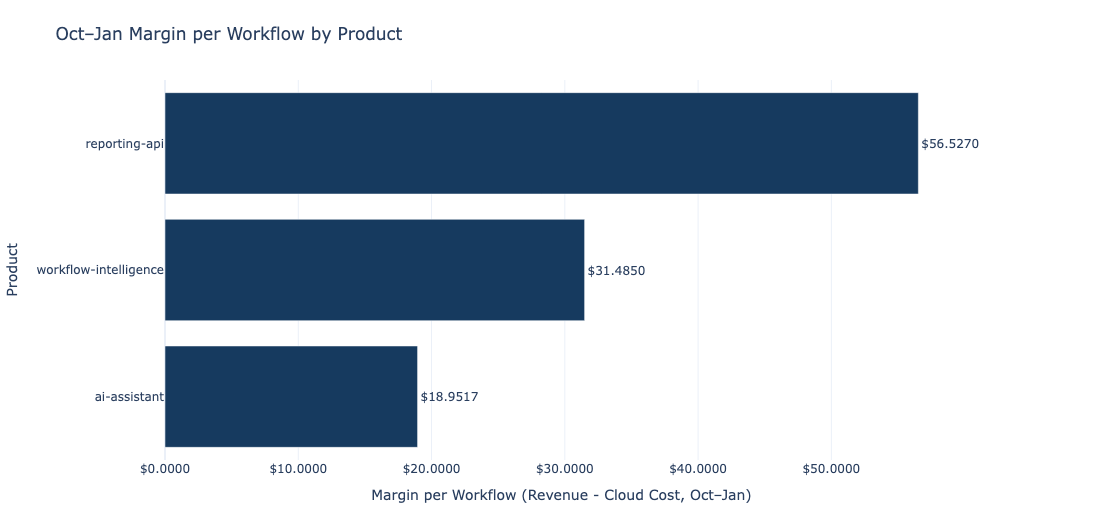

In [17]:
fig.update_traces(
    hovertemplate="<b>%{y}</b><br>Margin per workflow: $%{x:,.4f}<extra></extra>"
)

fig.show()

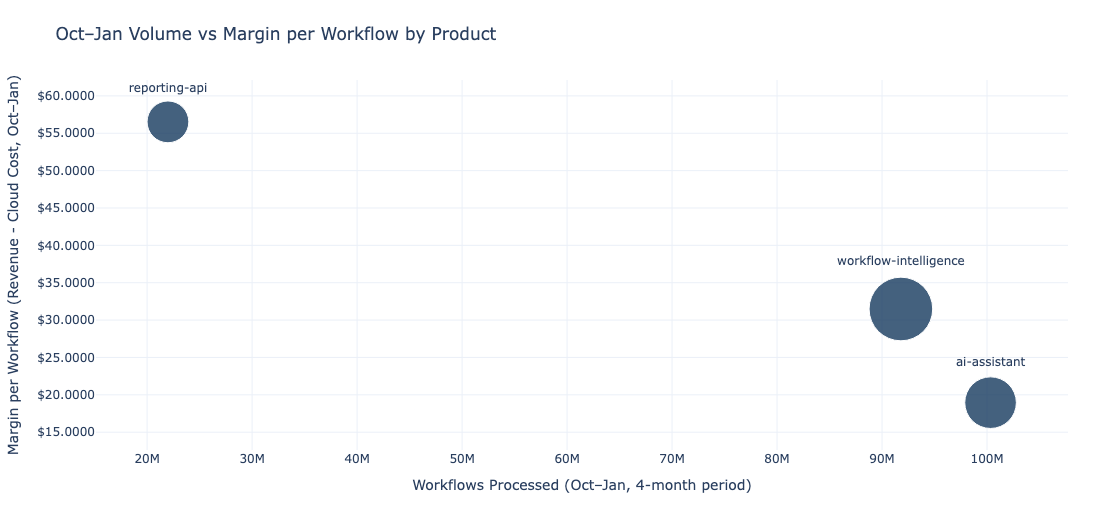

In [18]:

scatter_df = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

scatter_df = scatter_df[scatter_df["workflows_processed"] > 0].copy()

scatter_df["cost_per_workflow"] = (
    scatter_df["forecast_baseline_cost"] / scatter_df["workflows_processed"]
)

scatter_df["revenue_per_workflow"] = (
    scatter_df["monthly_revenue_proxy"] / scatter_df["workflows_processed"]
)

scatter_df["margin_per_workflow"] = (
    scatter_df["revenue_per_workflow"] - scatter_df["cost_per_workflow"]
)

fig = px.scatter(
    scatter_df,
    x="workflows_processed",
    y="margin_per_workflow",
    size="forecast_baseline_cost",
    size_max=45,
    text="product_name",
    title="Oct–Jan Volume vs Margin per Workflow by Product",
)

fig.update_traces(
    textposition="top center",
    marker=dict(color="#163A5F", opacity=0.8, line=dict(color="#ffffff", width=1)),
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Workflows processed: %{x:,.0f}<br>"
        "Margin per workflow: $%{y:,.4f}<br>"
        "Forecast baseline cost: $%{marker.size:,.0f}"
        "<extra></extra>"
    ),
)

fig.update_layout(
    template="plotly_white",
    height=520,
    xaxis_title="Workflows Processed (Oct–Jan, 4-month period)",
    yaxis_title="Margin per Workflow (Revenue - Cloud Cost, Oct–Jan)",
    yaxis_tickprefix="$",
    yaxis_tickformat=",.4f",
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(l=80, r=40, t=80, b=70),
)

fig.show()

In [19]:
# pursuing an "absolute economics view"

summary = (
    df.groupby("product_name", dropna=False)
      .agg({
          "forecast_baseline_cost": "sum",
          "monthly_revenue_proxy": "sum",
          "workflows_processed": "sum",
      })
      .reset_index()
)

summary["cost_per_workflow"] = summary["forecast_baseline_cost"] / summary["workflows_processed"]
summary["revenue_per_workflow"] = summary["monthly_revenue_proxy"] / summary["workflows_processed"]
summary["margin_per_workflow"] = summary["revenue_per_workflow"] - summary["cost_per_workflow"]

summary

,product_name,forecast_baseline_cost,monthly_revenue_proxy,workflows_processed,cost_per_workflow,revenue_per_workflow,margin_per_workflow
0,ai-assistant,2.717187e+08,2.173256e+09,100335822,2.708093,21.659824,18.951731
1,reporting-api,1.780858e+08,1.420863e+09,21985528,8.100136,64.627182,56.527046
2,workflow-intelligence,4.133779e+08,3.303570e+09,91795814,4.503233,35.988238,31.485005
